In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

In [2]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout, edwards, codebench, cs1eng

# Select a dataset by setting the config variable
config = codeworkout.S19

datasets_dir = os.path.join('..', '..', '..', 'sample_data')
dataset_paths = {
    # Edwards 2019 datasets is split into two semesters
    'edwards_f19': os.path.join(datasets_dir, 'edwards', '2019'),
    'edwards_s19': os.path.join(datasets_dir, 'edwards', '2019'),
}

if config.name in dataset_paths:
    dataset_root_dir = dataset_paths[config.name]
else:
    # Most datasets follow a simple naming convention
    dataset_name, dataset_semester = config.name.split('_')
    dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)

dataset = config.load(dataset_root_dir)

In [3]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [4]:
main_table = dataset.get_main_table()
main_table.head()

,Order,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation
0,0,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Run.Program,1.0,NaN,None,NaN,32-84779,NaN,NaN
1,1,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Compile,NaN,Success,None,NaN,32-84780,32-84779,NaN
2,2,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Run.Program,1.0,NaN,None,NaN,32-84781,NaN,NaN
3,3,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Compile,NaN,Success,None,NaN,32-84782,32-84781,NaN
4,4,4d230b683bf9840553ae57f4acc96e81,Java 8; CodeWorkout,2019-03-20 21:13:09,0,CS 1,1,492.0,32,1,23c57b36002c4d482df3d25f97778f74a2ed581a,True,Run.Program,0.0,NaN,None,NaN,32-84783,NaN,NaN


In [73]:
main_table = dataset.add_codestates(main_table)

In [67]:
from progsnap2.analytics.lc.learning_curves import KCEvaluator, KCEvaluation, LearningCurveCalculator
from progsnap2.spec.enums import CodeStatesTableColumns as CSTCols
from progsnap2.analytics.code.tokenize import python_tokenize
import re

token_pattern = re.compile(python_tokenize)

class NaiveKCEvaluator(KCEvaluator):
    def evaluate_attempts(self, attempts: pd.DataFrame) -> pd.DataFrame:
        first_attempt = attempts.iloc[0]
        code = first_attempt[CSTCols.Code]
        # Remove whitespace
        tokens = token_pattern.findall(code)
        tokens = [t for t in tokens if not t.isspace() and len(t) > 1]
        tokens = list(set(tokens))  # unique tokens
        is_correct = first_attempt[Cols.Score] >= 1
        correct = tokens if is_correct else []
        incorrect = tokens if not is_correct else []
        return KCEvaluation(correct=correct, incorrect=incorrect)

In [ ]:
sample_assignment_id = main_table[Cols.AssignmentID].iloc[0]
mt_subset = main_table[main_table[Cols.AssignmentID] == sample_assignment_id]

In [74]:
calc = LearningCurveCalculator(NaiveKCEvaluator(), main_table, config)

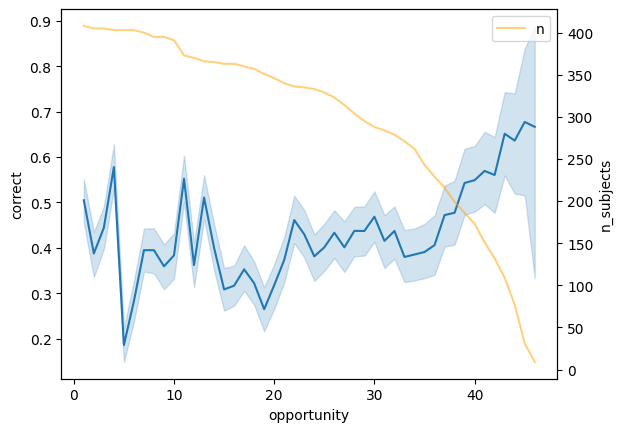

In [75]:
calc.plot_kc("if")

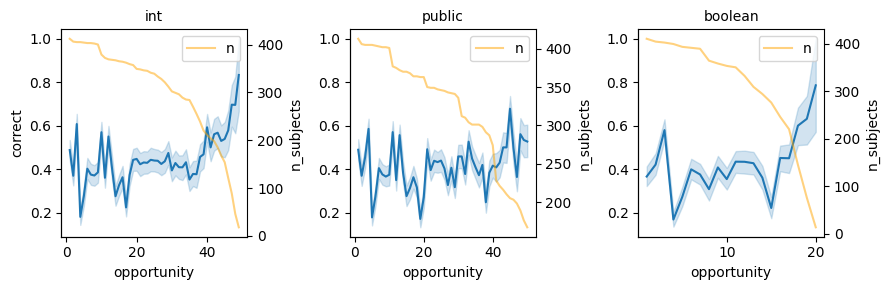

In [76]:
calc.plot_most_common_kcs(n=3)